In [1]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')
from IPython.display import clear_output

import python.forces as forces
import python.integrators as integrators
import python.random_matrix as random_matrix 
import python.simulate as simulate
import python.densities as densities

importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities);

---

#### Quick look at MALA.

In this version Euler-Maruyama is being used as the proposal. Eigenvalues cross very frequently for $dt > 1/N^2$, so it's likely $dt$ will need to scale $\sim \mathcal{O}(N^2)$ for reasonable results.

- Fix $N \in \{30, 70, 100\}$.
- For each $N$, try $dt \in \{\mathcal{O}(1)$, $~1/N$, $~1/N^2\}$.

Expect heavy rejects for $dt \neq \frac{1}{N^2}$. 

In [ ]:
N = 30;
dt_str = ["1/N", "1/NrootN", "1/N^7/4", "1/N^2"]
dt_range = [1/N, 1/(N**(3/2)), 1/(N**(7/4)), 1/(N**2)]
beta = 2.0; T = 5.0; M = 50; potential_name = "quartic"

config = {"track_accepts": True, "burn_in": 0}
new_obs_results = {}

for dt, dt_name in zip(dt_range, dt_str):
    burn_steps = int(3.0/dt); total_steps = int(T/dt);
    config["burn_in"] = burn_steps
    init = random_matrix.init_gue_eigenvalues(M, N)
    
    mala_pipe = simulate.make_mala_pipeline(N, dt, potential_name, beta)
    traj = simulate.simulate_dbm(init, total_steps, mala_pipe)
    all_info = simulate.analyse_trajectory(traj, total_steps, **config)

    new_obs_results[(dt_name)] = all_info

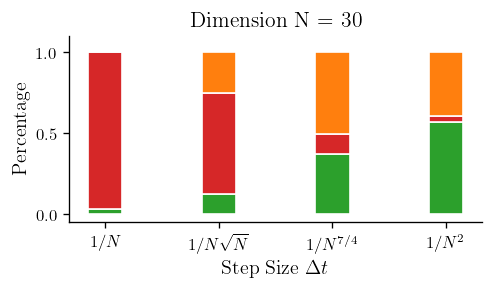

In [ ]:
dt_str_list = ["1/N", "1/NrootN", "1/N^7/4", "1/N^2"]
fig, ax = plt.subplots(figsize = (4, 2.3))

acceptances = [new_obs_results[(dt_str)]["accepts"].mean() for dt_str in dt_str_list]
cross_rejects = [new_obs_results[(dt_str)]["cross_rejects"].mean() for dt_str in dt_str_list]
other_rejects = [1 - acceptances[j] - cross_rejects[j] for j in range(len(acceptances))]

dt_str_list = [r"$1/N$", r"$1/N\sqrt{N}$", "$1/N^{7/4}$", "$1/N^2$"]
p1 = ax.bar(dt_str_list, acceptances, label = "Acceptances", color = '#2ca02c', edgecolor = 'white', width = 0.3)
p2 = ax.bar(dt_str_list, cross_rejects, bottom = acceptances, label = 'Rejects (Crossing)', color = '#d62728', edgecolor = 'white', width = 0.3)
p3 = ax.bar(dt_str_list, other_rejects, bottom = np.array(acceptances) + np.array(cross_rejects), label = 'Rejects (Other)', color = '#ff7f0e', edgecolor = 'white', width = 0.3)

ax.grid(False)
ax.set_ylim(-0.05, 1.1)

ax.set_ylabel("Percentage")
ax.set_xlabel("Step Size $\Delta t$")
ax.set_title(f"Dimension N = {N}")
ax.set_yticks([0, 0.5, 1])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.savefig(f"figures/mala-cross-rejects-N{N}.pdf", format = "pdf", dpi = 120)

plt.show()

---
---
---

In [2]:
importlib.reload(simulate);

In [ ]:
M = 100; beta = 2; pot_name = "quartic";
total_steps = 50000; target = 0.6;
N_range = [50, 70, 100]
method = "hmc"

last_accepts = np.zeros_like(N_range, dtype = float)
last_dts = np.zeros_like(N_range, dtype = float)
acc_histories = np.zeros_like(N_range, dtype = np.ndarray)
dt_histories = np.zeros_like(N_range, dtype = np.ndarray)

for j, N in enumerate(N_range):
    clear_output(wait = True)
    print(f"Running for N = {N}")

    init = random_matrix.init_gue_eigenvalues(M, N)
    dt_init = 1/N # Start near best guess..
    burn_steps = int(0.5/dt_init) # i.e. T_burn = 0.5.
    print(f"({burn_steps} burn-in steps)")

    accept_history, dt_history = simulate.target_dt(method, init, burn_steps, total_steps, pot_name, beta, dt_init, target)
    acc_histories[j] = accept_history; dt_histories[j] = dt_history
    
    last_accepts[j] = accept_history[-50:].mean()
    last_dts[j] = dt_history[-50:].mean()

Running for N = 100
(50 burn-in steps)


Accepts  [0.6248 0.6158 0.597 ]
[0.08647189 0.06494119 0.04737937]


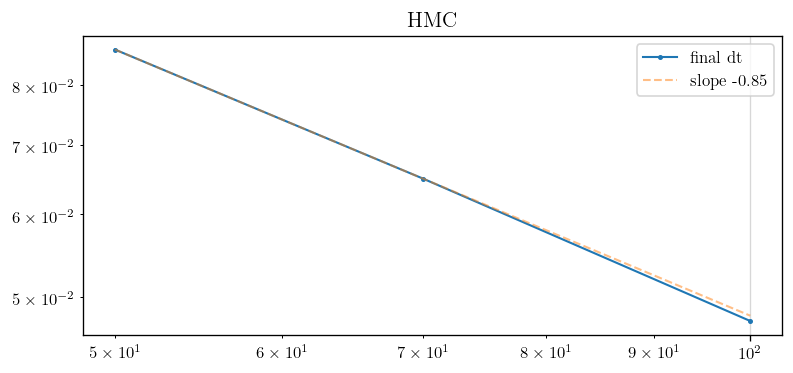

In [4]:
# Quick check on last accepts.
print(f"Accepts ", last_accepts)
print(last_dts)

fig, ax = plt.subplots()
ax.loglog(N_range, last_dts, label = "final dt", marker = 'o')

log_N = np.log10(N_range); log_dt = np.log10(last_dts);
slope, intercept = np.polyfit(log_N[0:-1], log_dt[0:-1], 1)
ax.plot(N_range, 10**(intercept)*N_range**slope, linestyle = "--", alpha = 0.5, label = f"slope {slope:.2f}")
ax.set_title(method.upper())

ax.legend()
plt.show()

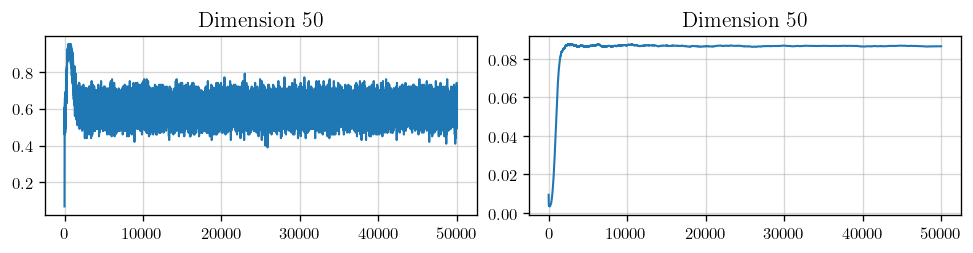

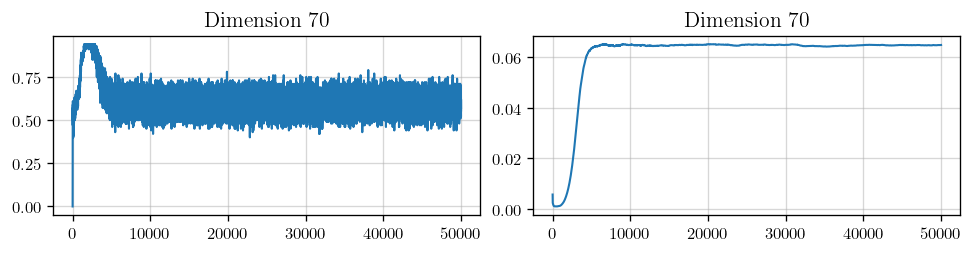

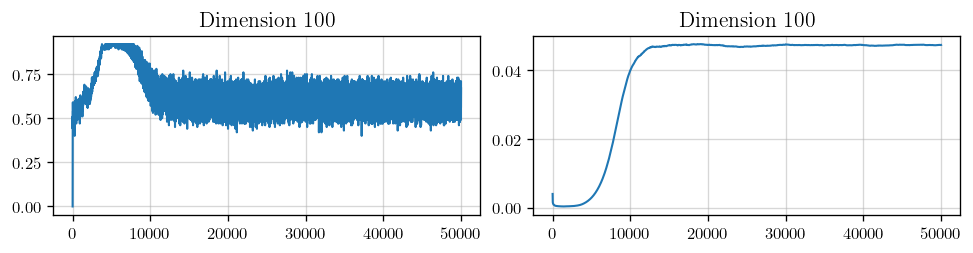

In [5]:
# Trace plots for these Ns.
for j, N in enumerate(N_range):
    fig, axes = plt.subplots(1, 2, figsize = (8, 2))
    axes[0].plot(acc_histories[j])
    axes[1].plot(dt_histories[j])

    for ax in axes:
        ax.set_title(f"Dimension {N}")

    plt.show()

In [22]:
# Save the results.
import pickle

data = {}
for j, N in enumerate(N_range):
    key = (N, method) # (N, "hmc") for instance.

    data[key] = {
        "N": N, "M": M, "pot_name": pot_name,
        "burn_steps": int(0.5/(1/N)), "total_steps": total_steps,
        "num_last_avg": 50, # Hard coded in loop.
        "last_accepts": last_accepts[j], "last_dts": last_dts[j],
        "all_accepts": acc_histories[j], "all_dts": dt_histories[j]
    }

filename = f"data/{method}-N{','.join(map(str, N_range))}.pkl"
with open(filename, 'wb') as f:
    pickle.dump(data, f)

print(f"Data saved to {filename}.")

Data saved to data/hmc-N50,70,100.pkl.
